# K-Means sobre Dry Bean Dataset

## Objetivos de la práctica
En este notebook vamos a construir un flujo completo de *clustering* con **K-Means** sobre el dataset **Dry Bean**:

- Cargar el dataset.
- Escalar variables con `StandardScaler`.
- Visualizar clusters en 3D usando características reales del dataset.
- Entrenar K-Means para `k = 3, 5, 7, 9` y evaluar con **inercia** y **silhouette**.
- Comparar resultados en una tabla resumen.
- (Opcional) Analizar `cluster vs clase real` para `k=7`.
- (Opcional) Explorar `k` con codo + silhouette.


In [1]:
# 2) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
RANDOM_STATE = 42


In [2]:
# 3) Carga del dataset Dry Bean (ruta clara y directa)
data_path = "../Datasets/DryBeanDataset/Dry_Bean_Dataset.xlsx"
# Alternativa si tenés CSV:
# data_path = "../Datasets/DryBeanDataset/Dry_Bean_Dataset.csv"

df = pd.read_excel(data_path)  # Requiere: openpyxl

print(f"Archivo cargado: {data_path}")
print(f"Shape: {df.shape}")
display(df.head(3))


Archivo cargado: ../Datasets/DryBeanDataset/Dry_Bean_Dataset.xlsx
Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER


In [3]:
# 4) Features + StandardScaler
# En este dataset la columna real de clase es "Class"
target_col = "Class"

X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()
y_real = df[target_col].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features numéricas: {X.shape[1]}")
print(f"Clases reales: {y_real.nunique()}")


Features numéricas: 16
Clases reales: 7


Características usadas en gráfico 3D:
['Area', 'Perimeter', 'MajorAxisLength']


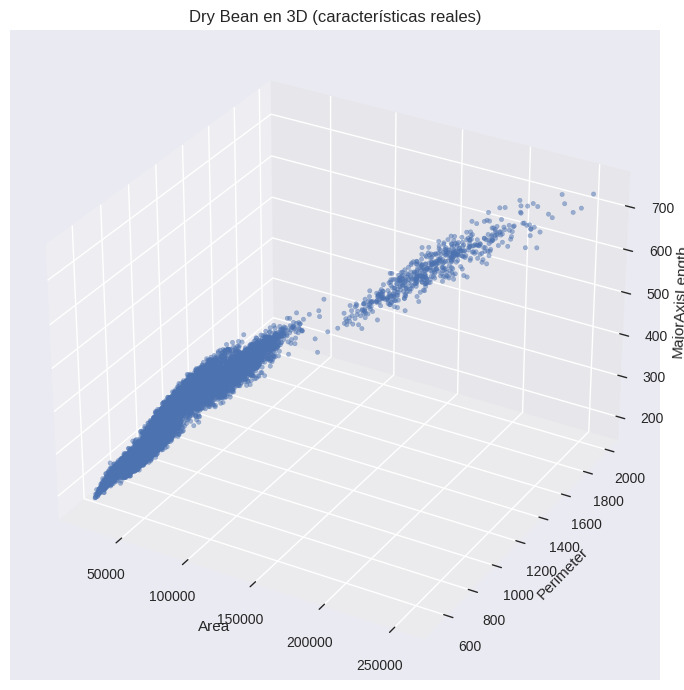

In [4]:
# 5) Selección de 3 características reales para visualización 3D
preferred_features = ["Area", "Perimeter", "MajorAxisLength"]

if all(col in X.columns for col in preferred_features):
    features_3d = preferred_features
else:
    features_3d = list(X.columns[:3])

X_plot_3d = X[features_3d].copy()

print("Características usadas en gráfico 3D:")
print(features_3d)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_plot_3d.iloc[:, 0], X_plot_3d.iloc[:, 1], X_plot_3d.iloc[:, 2], s=10, alpha=0.5)
ax.set_title("Dry Bean en 3D (características reales)")
ax.set_xlabel(features_3d[0])
ax.set_ylabel(features_3d[1])
ax.set_zlabel(features_3d[2])
plt.tight_layout()
plt.show()


In [5]:
# 6) KMeans con k=3,5,7,9 + métricas
k_values = [3, 5, 7, 9]
resultados = []
labels_por_k = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    sil = silhouette_score(X_scaled, labels)

    labels_por_k[k] = labels
    resultados.append({"k": k, "inercia": inertia, "silhouette": sil})

    print(f"k={k} | inercia={inertia:,.2f} | silhouette={sil:.4f}")


k=3 | inercia=94,741.99 | silhouette=0.4047
k=5 | inercia=61,893.64 | silhouette=0.3569
k=7 | inercia=48,811.96 | silhouette=0.3094
k=9 | inercia=41,975.59 | silhouette=0.3033


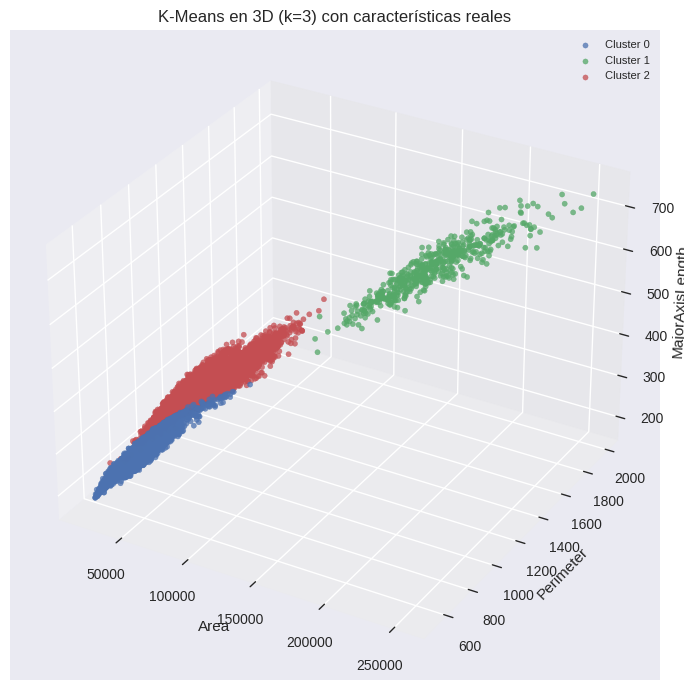

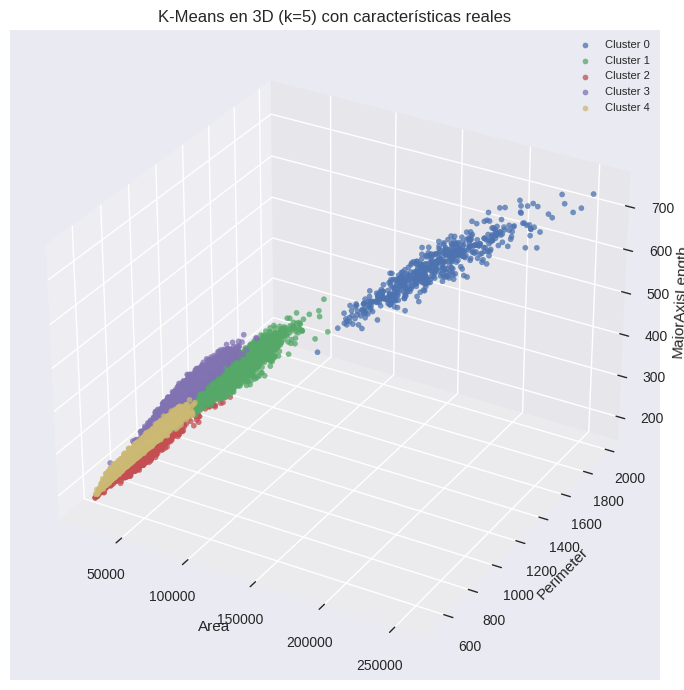

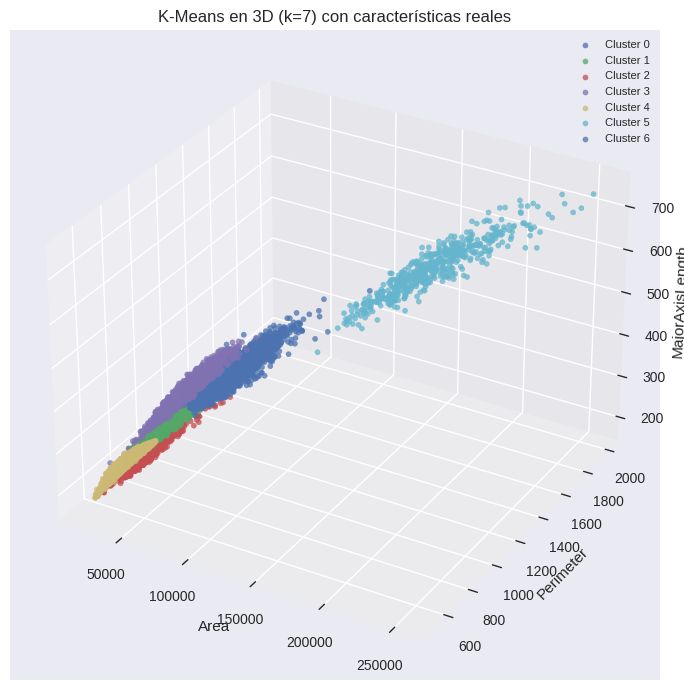

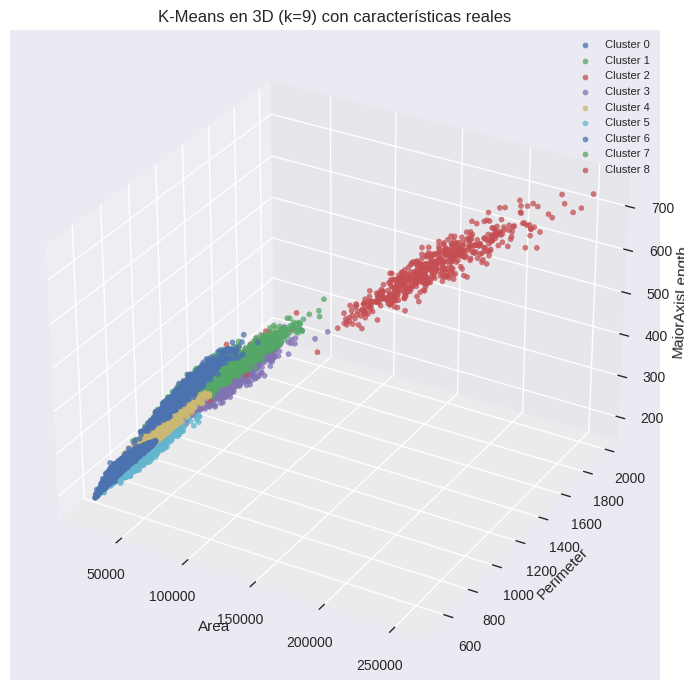

In [6]:
# 7) Gráficos 3D de clusters para cada k (características reales)
for k in k_values:
    labels = labels_por_k[k]

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        ax.scatter(
            X_plot_3d.loc[mask, features_3d[0]],
            X_plot_3d.loc[mask, features_3d[1]],
            X_plot_3d.loc[mask, features_3d[2]],
            s=14,
            alpha=0.75,
            label=f"Cluster {cluster_id}",
        )

    ax.set_title(f"K-Means en 3D (k={k}) con características reales")
    ax.set_xlabel(features_3d[0])
    ax.set_ylabel(features_3d[1])
    ax.set_zlabel(features_3d[2])
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


In [7]:
# 8) Tabla resumen
df_resultados = pd.DataFrame(resultados).sort_values("k").reset_index(drop=True)
display(df_resultados)


,k,inercia,silhouette
0,3,94741.986565,0.404745
1,5,61893.644352,0.356898
2,7,48811.956426,0.309380
3,9,41975.594825,0.303298


In [8]:
# 9) Promedio por cluster (interpretación) para k=7
df_k7 = X.copy()
df_k7["cluster_k7"] = labels_por_k[7]
display(df_k7.groupby("cluster_k7").mean().round(2))


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
cluster_k7,,,,,,,,,,,,,,,,
0,74020.45,1060.52,394.22,240.08,1.65,0.79,75137.55,306.39,0.76,0.99,0.83,0.78,0.01,0.0,0.61,0.99
1,44435.41,794.08,298.23,190.05,1.57,0.77,44973.00,237.47,0.75,0.99,0.88,0.80,0.01,0.0,0.64,1.00
2,39397.05,721.92,248.67,201.35,1.24,0.58,39780.23,223.50,0.77,0.99,0.95,0.90,0.01,0.0,0.81,1.00
3,53676.97,919.90,373.68,183.38,2.04,0.87,54381.85,260.82,0.70,0.99,0.79,0.70,0.01,0.0,0.49,0.99
4,31541.08,658.12,243.26,164.90,1.48,0.73,31910.48,199.91,0.76,0.99,0.91,0.82,0.01,0.0,0.68,1.00
5,173667.57,1586.45,593.53,374.53,1.59,0.77,175992.07,469.21,0.78,0.99,0.86,0.79,0.00,0.0,0.63,0.99
6,65249.22,1004.00,385.95,216.96,1.79,0.82,67014.56,286.43,0.73,0.97,0.80,0.74,0.01,0.0,0.55,0.98


In [9]:
# 10) (Opcional) Crosstab cluster vs clase real para k=7
ct = pd.crosstab(labels_por_k[7], y_real, rownames=["cluster_k7"], colnames=["clase_real"])
print("Tabla de contingencia (conteos):")
display(ct)

print("Tabla de contingencia normalizada por fila (%):")
display((ct.div(ct.sum(axis=1), axis=0) * 100).round(2))


Tabla de contingencia (conteos):


clase_real,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
cluster_k7,,,,,,,
0,1142,1,1303,0,29,0,5
1,114,0,25,499,49,98,2326
2,18,0,2,115,0,1874,24
3,8,0,30,7,1661,0,63
4,0,0,0,2912,2,52,191
5,0,520,0,0,0,0,0
6,40,1,270,13,187,3,27


Tabla de contingencia normalizada por fila (%):


clase_real,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
cluster_k7,,,,,,,
0,46.05,0.04,52.54,0.00,1.17,0.00,0.20
1,3.66,0.00,0.80,16.04,1.58,3.15,74.77
2,0.89,0.00,0.10,5.66,0.00,92.18,1.18
3,0.45,0.00,1.70,0.40,93.89,0.00,3.56
4,0.00,0.00,0.00,92.24,0.06,1.65,6.05
5,0.00,100.00,0.00,0.00,0.00,0.00,0.00
6,7.39,0.18,49.91,2.40,34.57,0.55,4.99


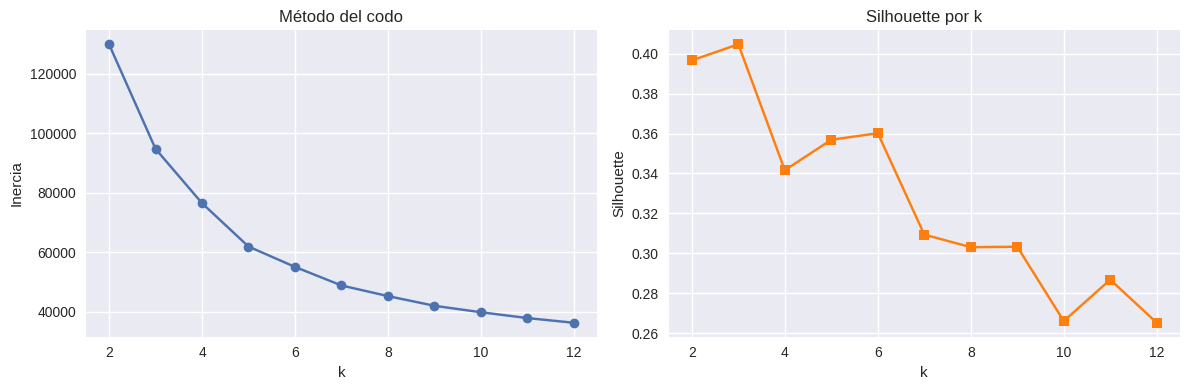

k sugerido por silhouette (máximo): 3


In [10]:
# 11) (Opcional) Codo + silhouette para rango de k
k_range = range(2, 13)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(list(k_range), inertias, marker="o")
axs[0].set_title("Método del codo")
axs[0].set_xlabel("k")
axs[0].set_ylabel("Inercia")

axs[1].plot(list(k_range), silhouettes, marker="s", color="tab:orange")
axs[1].set_title("Silhouette por k")
axs[1].set_xlabel("k")
axs[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

k_opt_sil = list(k_range)[int(np.argmax(silhouettes))]
print(f"k sugerido por silhouette (máximo): {k_opt_sil}")
